# Homework 8: Optimization Algorithms in Python

**Course:** MATH 4420/5420 - Optimization

**Total Points:** 100 (10 problems × 10 points each)

**Instructions:**
- Complete all code cells marked with `# YOUR CODE HERE`
- Answer all markdown questions in the designated cells
- Show all work and include comments explaining your code
- Include all requested plots and interpretations

**Topics Covered:**
1. Gradient Descent (constant step size, backtracking, exact line search)
2. Condition Numbers and Convergence
3. Newton's Method
4. Convex Optimization with CVXPY

---
## Setup: Import Required Libraries

Run this cell first to import all necessary libraries.

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from numpy.linalg import norm, inv, eigvals

# Install cvxpy if needed (uncomment the line below if you need to install)
# !pip install cvxpy
import cvxpy as cp

# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = [8, 6]
plt.rcParams['font.size'] = 12


---
# Part 1: Gradient Descent (40 points)

In this section, you will implement gradient descent with three different step size strategies:
1. Constant step size
2. Backtracking line search
3. Exact line search (for quadratic functions)

You will also explore how the **condition number** of a problem affects convergence speed.

## Background: Condition Number

For a quadratic function $f(\mathbf{x}) = \frac{1}{2}\mathbf{x}^T Q \mathbf{x} - \mathbf{b}^T \mathbf{x}$, the **condition number** is defined as:

$$\kappa(Q) = \frac{\lambda_{\max}(Q)}{\lambda_{\min}(Q)}$$

where $\lambda_{\max}$ and $\lambda_{\min}$ are the largest and smallest eigenvalues of $Q$.

- **Well-conditioned problems** have $\kappa \approx 1$ (eigenvalues are similar)
- **Ill-conditioned problems** have $\kappa \gg 1$ (eigenvalues vary widely)

Gradient descent converges slowly on ill-conditioned problems because the gradient direction can be nearly orthogonal to the direction toward the minimum.

## Example: Gradient Descent with Constant Step Size

Below is a complete implementation of gradient descent with constant step size, applied to the function:

$$f(x, y) = x^2 + y^2$$

This function has:
- Gradient: $\nabla f(x, y) = [2x, 2y]^T$
- Hessian: $H = \begin{bmatrix} 2 & 0 \\ 0 & 2 \end{bmatrix}$
- Condition number: $\kappa = \frac{2}{2} = 1$ (perfectly conditioned!)
- Minimum at $(0, 0)$ with $f^* = 0$

**Study this example carefully** — you will adapt this code for the problems below.

In [3]:
# EXAMPLE: Gradient Descent with Constant Step Size
# Function: f(x, y) = x^2 + y^2

def f_example(x):
    """Objective function: f(x,y) = x^2 + y^2"""
    return x[0]**2 + x[1]**2

def grad_f_example(x):
    """Gradient of f(x,y) = x^2 + y^2"""
    return np.array([2*x[0], 2*x[1]])

def gradient_descent_constant(f, grad_f, x0, step_size, tol=1e-6, max_iter=1000):
    """
    Gradient descent with constant step size.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of the objective function
    x0 : numpy array
        Initial point
    step_size : float
        Constant step size (learning rate)
    tol : float
        Stopping tolerance (stop when ||grad|| < tol)
    max_iter : int
        Maximum number of iterations
        
    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values at each iterate
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]
    
    for k in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break
        
        # Gradient descent update
        x = x - step_size * grad
        
        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))
    
    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # Remember that k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")
    
    return x_history, f_history

# Run gradient descent
x0 = np.array([5.0, 5.0])  # Starting point
step_size = 0.1            # Constant step size

x_hist, f_hist = gradient_descent_constant(f_example, grad_f_example, x0, step_size)

print(f"\nFinal point: ({x_hist[-1][0]:.6f}, {x_hist[-1][1]:.6f})")
print(f"Final function value: {f_hist[-1]:.10f}")
print(f"Number of iterations: {len(f_hist) - 1}")

Converged in 74 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 74


### Example: Convergence Plot

A **convergence plot** shows how the function value (or gradient norm) decreases over iterations. This is essential for comparing different optimization methods.

**You will adapt this plotting code for your problems below.**

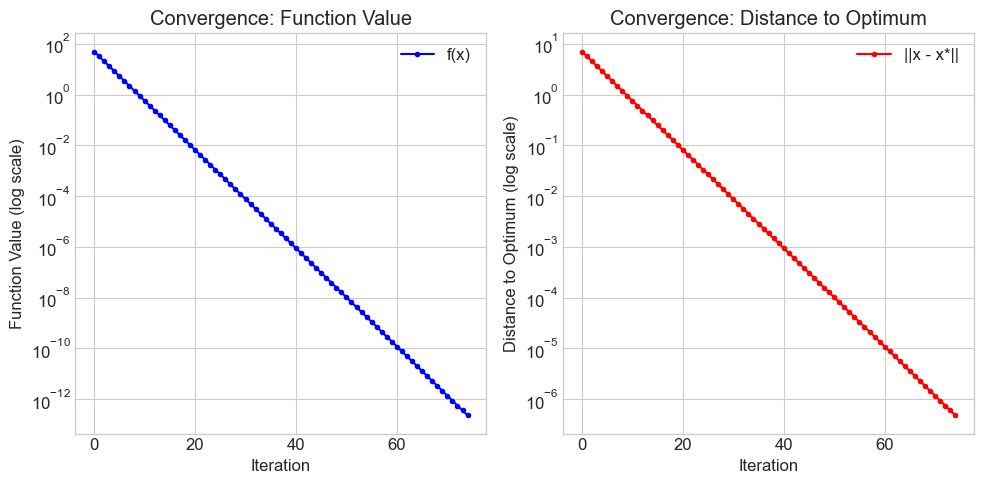

The log-linear appearance indicates LINEAR convergence rate.


In [4]:
# EXAMPLE: Convergence Plot

plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist, 'b-o', markersize=3, label='f(x)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([0.0, 0.0])  # Known optimum
distances = [norm(x - x_star) for x in x_hist]
plt.semilogy(distances, 'r-o', markersize=3, label='||x - x*||')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

print("The log-linear appearance indicates LINEAR convergence rate.")

---
## Problem 1 (10 points): Gradient Descent with Constant Step Size

Implement gradient descent with **constant step size** for the function:

$$f(x, y) = x^2 + 10y^2$$

**Tasks:**

**(a)** Compute the Hessian matrix and find its eigenvalues. What is the condition number $\kappa$? Do this by hand and record your answer in the Markdown box labeled "Your Answer for part (a)."

**(b)** Implement the function `f1` and its gradient `grad_f1`.

**(c)** Run gradient descent from $\mathbf{x}_0 = (5, 5)^T$ with step size $t = 0.05$. Report the number of iterations to converge.

**(d)** Create a convergence plot showing function value vs. iteration.

**(e)** Compare the number of iterations with the example above ($\kappa = 1$). How does the condition number affect convergence?

### Your Answer for Part (a):

$ f(x, y) = x^2 + 10y^2$

$ \nabla f(x, y) = [2x,  20y]^T$

$ \nabla^2 f(x, y) = \begin{bmatrix} 2 & 0 \\ 0 & 20 \end{bmatrix} $

The condition number $\kappa$ is $20 \div 2 = 10$.

In [11]:
# Problem 1(b): Define the function and gradient

def f1(x):
    """Objective function: f(x,y) = x^2 + 10*y^2"""
    return x[0]**2 + 10*x[1]**2

def grad_f1(x):
    """Gradient of f(x,y) = x^2 + 10*y^2"""
    return np.array([2*x[0], 20*x[1]])

# Test your functions
x_test = np.array([1.0, 1.0])
print(f"f(1,1) = {f1(x_test)}")  # Should be 11
print(f"grad_f(1,1) = {grad_f1(x_test)}")  # Should be [2, 20]

f(1,1) = 11.0
grad_f(1,1) = [ 2. 20.]


In [137]:
# Problem 1(c): Run gradient descent
import time
start_time = time.time()

x0 = np.array([5.0, 5.0])
step_size = 0.05

def gradient_descent_constant(f, grad_f, x0, step_size, tol=1e-6, max_iter=1000):
    """
    Gradient descent with constant step size.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of the objective function
    x0 : numpy array
        Initial point
    step_size : float
        Constant step size (learning rate)
    tol : float
        Stopping tolerance (stop when ||grad|| < tol)
    max_iter : int
        Maximum number of iterations
        
    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values at each iterate
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]
    
    for k in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break
        
        # Gradient descent update
        x = x - step_size * grad
        
        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))
    
    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # Remember that k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")
    
    return x_history, f_history

x_hist, f_hist = gradient_descent_constant(f1, grad_f1, x0, step_size)

print(f"\nFinal point: ({x_hist[-1][0]:.6f}, {x_hist[-1][1]:.6f})")
print(f"Final function value: {f_hist[-1]:.10f}")
print(f"Number of iterations: {len(f_hist) - 1}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))


Converged in 153 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 153
--- 2.932310104370117 ms ---


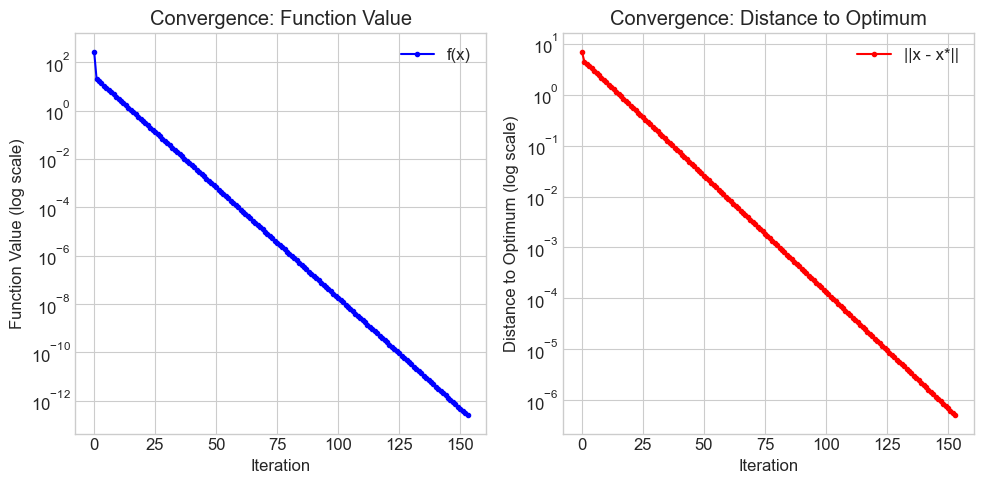

In [ ]:
# Problem 1(d): Create convergence plot

plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist, 'b-o', markersize=3, label='f(x)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([0.0, 0.0])  # Known optimum
distances = [norm(x - x_star) for x in x_hist]
plt.semilogy(distances, 'r-o', markersize=3, label='||x - x*||')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Your Answer for Part (e):

The example function converged in 74 iterations with $\kappa = 1$, while the function in problem 1 took 153 iterations to converge with $\kappa = 10$. Better conditioned problems converge more quickly.


---
## Problem 2 (10 points): Gradient Descent with Backtracking Line Search

Implement gradient descent with **backtracking (Armijo) line search** for the same function:

$$f(x, y) = x^2 + 10y^2$$

**Backtracking Line Search Algorithm:**

Given parameters $\alpha \in (0, 0.5)$ and $\beta \in (0, 1)$:
1. Start with $t = 1$
2. While $f(\mathbf{x} - t\nabla f(\mathbf{x})) > f(\mathbf{x}) - \alpha t \|\nabla f(\mathbf{x})\|^2$:
   - Update $t \leftarrow \beta t$
3. Return $t$

**Tasks:**

**(a)** Implement the `backtracking_line_search` function.

**(b)** Implement `gradient_descent_backtracking` using your backtracking function.

**(c)** Run gradient descent from $\mathbf{x}_0 = (5, 5)^T$ with $\alpha = 0.3$ and $\beta = 0.8$.

**(d)** Create a convergence plot and compare with Problem 1.

In [26]:
# Problem 2(a): Implement backtracking line search

def backtracking_line_search(f, grad_f, x, alpha=0.3, beta=0.8):
    """
    Backtracking line search to find step size satisfying Armijo condition.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    x : numpy array
        Current point
    alpha : float
        Armijo parameter (typically 0.1 to 0.4)
    beta : float
        Step size reduction factor (typically 0.5 to 0.9)
        
    Returns:
    --------
    t : float
        Step size satisfying Armijo condition
    """
    t = 1.0  # Initial step size
    grad = grad_f(x)
    
    while f(x - t*grad_f(x)) > f(x) - alpha * t * np.linalg.norm(grad)**2:
        t = beta*t
        
    return t

In [16]:
# Problem 2(b): Implement gradient descent with backtracking

def gradient_descent_backtracking(f, grad_f, x0, alpha=0.3, beta=0.8, tol=1e-6, max_iter=1000):
    """
    Gradient descent with backtracking line search.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    x0 : numpy array
        Initial point
    alpha : float
        Armijo parameter
    beta : float
        Step size reduction factor
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations
        
    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]
    
    for k in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break
        
        step_size = backtracking_line_search(f, grad_f, x, alpha, beta)

        # Gradient descent update
        x = x - step_size * grad
        
        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))
    
    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # Remember that k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")
    
    return x_history, f_history

In [138]:
# Problem 2(c): Run gradient descent with backtracking
import time
start_time = time.time()

x0 = np.array([5.0, 5.0])
alpha=0.3
beta=0.8

x_hist_bt, f_hist_bt = gradient_descent_backtracking(f1, grad_f1, x0, alpha, beta)

print(f"\nFinal point: ({x_hist_bt[-1][0]:.6f}, {x_hist_bt[-1][1]:.6f})")
print(f"Final function value: {f_hist_bt[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_bt) - 1}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))

Converged in 84 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 84
--- 15.792369842529297 ms ---


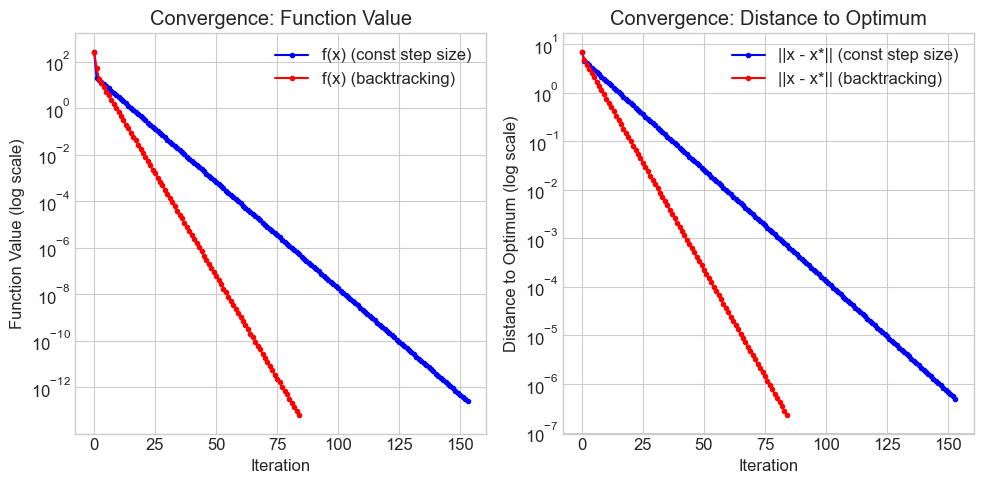

In [32]:
# Problem 2(d): Convergence plot comparing constant step size and backtracking

plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist, 'b-o', markersize=3, label='f(x) (const step size)')
plt.semilogy(f_hist_bt, 'r-o', markersize=3, label='f(x) (backtracking)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([0.0, 0.0])  # Known optimum
distances = [norm(x - x_star) for x in x_hist]
distances_bt = [norm(x - x_star) for x in x_hist_bt]
plt.semilogy(distances, 'b-o', markersize=3, label='||x - x*|| (const step size)')
plt.semilogy(distances_bt, 'r-o', markersize=3, label='||x - x*|| (backtracking)')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---
## Problem 3 (10 points): Gradient Descent with Exact Line Search

For **quadratic functions** of the form $f(\mathbf{x}) = \mathbf{x}^T Q \mathbf{x} + 2\mathbf{b}^T \mathbf{x} + c$, the optimal step size can be computed exactly:

$$t^* = \frac{\|\nabla f(\mathbf{x})\|^2}{2\nabla f(\mathbf{x})^T Q \nabla f(\mathbf{x})}$$

**Tasks:**

**(a)** Implement `gradient_descent_exact` for quadratic functions.

**(b)** Apply to $f(x, y) = x^2 + 10y^2$ (note: $Q = \begin{bmatrix} 1 & 0 \\ 0 & 10 \end{bmatrix}$, $\mathbf{b} = \mathbf{0}$, $c=0$).

**(c)** Create a convergence plot comparing all three methods (constant, backtracking, exact).

**(d)** Which method converges fastest? Why?

In [140]:
# Problem 3(a): Implement gradient descent with exact line search

def gradient_descent_exact(f, grad_f, Q, x0, tol=1e-6, max_iter=1000):
    """
    Gradient descent with exact line search for quadratic functions.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    Q : numpy array
        Hessian matrix (for quadratic: f(x) = 0.5*x'Qx - b'x + c)
    x0 : numpy array
        Initial point
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations
        
    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]
    
    for k in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break

        step_size = np.linalg.norm(grad)**2 / (2*np.transpose(grad) @ Q @ grad)

        # Gradient descent update
        x = x - step_size * grad
        
        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))
    
    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # Remember that k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")
    
    return x_history, f_history

In [141]:
# Problem 3(b): Apply to f(x,y) = x^2 + 10y^2
import time
start_time = time.time()

# Define the Hessian matrix Q
Q1 = np.array([[2, 0], [0, 20]])  # Hessian of f(x,y) = x^2 + 10y^2

x0 = np.array([5.0, 5.0])

x_hist_exact, f_hist_exact = gradient_descent_exact(f1, grad_f1, Q1, x0)

print(f"\nFinal point: ({x_hist_exact[-1][0]:.6f}, {x_hist_exact[-1][1]:.6f})")
print(f"Final function value: {f_hist_exact[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_exact) - 1}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))

Converged in 55 iterations!

Final point: (0.000000, -0.000000)
Final function value: 0.0000000000
Number of iterations: 55
--- 4.6539306640625 ms ---


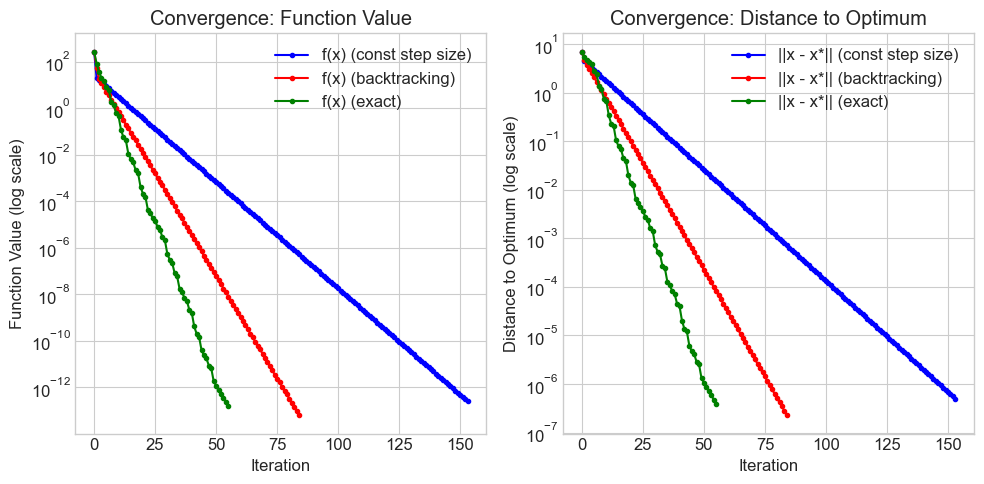

In [78]:
# Problem 3(c): Convergence plot comparing all three methods

# YOUR CODE HERE: Create a single plot with all three convergence curves
plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist, 'b-o', markersize=3, label='f(x) (const step size)')
plt.semilogy(f_hist_bt, 'r-o', markersize=3, label='f(x) (backtracking)')
plt.semilogy(f_hist_exact, 'g-o', markersize=3, label='f(x) (exact)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([0.0, 0.0])  # Known optimum
distances = [norm(x - x_star) for x in x_hist]
distances_bt = [norm(x - x_star) for x in x_hist_bt]
distances_exact = [norm(x - x_star) for x in x_hist_exact]
plt.semilogy(distances, 'b-o', markersize=3, label='||x - x*|| (const step size)')
plt.semilogy(distances_bt, 'r-o', markersize=3, label='||x - x*|| (backtracking)')
plt.semilogy(distances_exact, 'g-o', markersize=3, label='||x - x*|| (exact)')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Your Answer for Part (d):

Exact line search converges the fastest. This is because it mathematically computes the perfect step size to minimize the total number of steps required. Just for fun I added some code snippets to time the execution of each function. While constant step size takes the most iterations to coverge, it is actually the fastest to compute for this function, taking only 3ms. 


---
## Problem 4 (10 points): Ill-Conditioned Problem (Rosenbrock Function)

Now apply all three gradient descent methods to the **ill-conditioned** function:

$$f(x_1, x_2) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$$

This is the famous **Rosenbrock function**, known for being difficult to optimize.

**Tasks:**

**(a)** Compute the gradient $\nabla f$ and Hessian $\nabla^2 f$ analytically.

**(b)** The minimum is at $(1, 1)$. Compute the Hessian at this point and find its condition number.

**(c)** Implement `f_rosenbrock` and `grad_f_rosenbrock`.

**(d)** Run all three gradient descent methods from $\mathbf{x}_0 = (-1, 1)^T$ with `max_iter=10000`.

**(e)** Create a convergence plot comparing all three methods. What do you observe about convergence speed compared to the well-conditioned problems?

In [ ]:
from sympy import Symbol, Matrix, Abs

def f(x1, x2):
    return 110*(x2 - x1**2)**2 + (1-x1)**2

x1 = Symbol('x1')
x2 = Symbol('x2')

expr = f(x1, x2)

gradient = Matrix([expr.diff(x) for x in [x1, x2]])
hessian = Matrix([[expr.diff(x).diff(y) for y in [x1, x2]] for x in [x1, x2]])

print("Gradient:")
print(gradient)
print('Hessian:')
print(hessian)
print(f'Hessian of (1, 1) is:')
H = hessian.subs([(x1, 1), (x2, 1)])
print(H)

eigenvalues = list(H.eigenvals().keys())
condition_number = max(Abs(e) for e in eigenvalues) / min(Abs(e) for e in eigenvalues)
print('Condition number:')
print(condition_number)
print(f'≈ {(17*np.sqrt(1049) + 551)/(551 - 17*np.sqrt(1049))}') # just copy-pasted

Gradient:
Matrix([[-440*x1*(-x1**2 + x2) + 2*x1 - 2], [-220*x1**2 + 220*x2]])
Hessian:
Matrix([[1320*x1**2 - 440*x2 + 2, -440*x1], [-440*x1, 220]])
Hessian of (1, 1) is:
Matrix([[882, -440], [-440, 220]])
Condition number:
(17*sqrt(1049) + 551)/(551 - 17*sqrt(1049))
≈ 2758.0087283285266


### Your Answer for Parts (a) and (b):

**Gradient:** $ \begin{bmatrix} -440 x_1 (-x_1^2 + x_2) + 2x_1 - 2 \\ -220x_1^2 + 220x_2 \end{bmatrix}$

**Hessian:** $\begin{bmatrix} 1320x_1^2 - 440x_2 + 2, & -440x_1 \\ -440x_1, & 220 \end{bmatrix} $

**Hessian at (1,1):** $\begin{bmatrix} 882, & -440 \\ -440, & 220 \end{bmatrix} $

**Condition number:** $\frac{17\sqrt{1049} + 551}{551 - 17\sqrt{1049}} \approxeq 2758.0087283285266 $


In [117]:
# Problem 4(c): Implement the Rosenbrock-like function

def f_rosenbrock(x):
    """Rosenbrock-like function: f(x1,x2) = 100(x2 - x1^2)^2 + (1 - x1)^2"""
    return 110*(x[1] - x[0]**2)**2 + (1-x[0])**2

def grad_f_rosenbrock(x):
    """Gradient of Rosenbrock-like function"""
    return np.array([-440*x[0]*(-x[0]**2 + x[1]) + 2*x[0] - 2, -220*x[0]**2 + 220*x[1]])

# Test your functions
x_test = np.array([1.0, 1.0])
print(f"f(1,1) = {f_rosenbrock(x_test)}")  # Should be 0
print(f"grad_f(1,1) = {grad_f_rosenbrock(x_test)}")  # Should be [0, 0]

f(1,1) = 0.0
grad_f(1,1) = [0. 0.]


In [150]:
# Problem 4(d): Run all three gradient descent methods

x0_ros = np.array([-1.0, 1.0])
max_iter_ros = 10000

def gradient_descent_exact(f, grad_f, x0, tol=1e-6, max_iter=1000):
    """
    Gradient descent with exact line search for quadratic functions.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    Q : numpy array
        Hessian matrix (for quadratic: f(x) = 0.5*x'Qx - b'x + c)
    x0 : numpy array
        Initial point
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations
        
    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]
    
    for k in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Converged in {k} iterations!")
            break

        from scipy.optimize import minimize_scalar

        # little numeric computation to determine step size
        phi = lambda a: f(x - a * grad)
        res = minimize_scalar(phi)

        step_size = res.x

        # Gradient descent update
        x = x - step_size * grad
        
        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))
    
    # Check if we reached maximum iterations without convergence
    if k == max_iter - 1: # Remember that k starts at 0, so we need to check for max_iter - 1
        print(f"Maximum iterations ({max_iter}) reached.")
    
    return x_history, f_history

# Print results for each method
# YOUR CODE HERE
# Problem 3(b): Apply to f(x,y) = x^2 + 10y^2
import time
start_time = time.time()

x0 = np.array([-1, 1])

print('========== Exact Line Search ==========')

x_hist_exact, f_hist_exact = gradient_descent_exact(f_rosenbrock, grad_f_rosenbrock, x0, max_iter=100000)

print(f"\nFinal point: ({x_hist_exact[-1][0]:.6f}, {x_hist_exact[-1][1]:.6f})")
print(f"Final function value: {f_hist_exact[-1]:.10f}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))

start_time = time.time()
print()
print('========== Constant Step Size ==========')

x_hist_c, f_hist_c = gradient_descent_constant(f_rosenbrock, grad_f_rosenbrock, x0, step_size=0.001,  max_iter=100000)

print(f"\nFinal point: ({x_hist_exact[-1][0]:.6f}, {x_hist_exact[-1][1]:.6f})")
print(f"Final function value: {f_hist_exact[-1]:.10f}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))

start_time = time.time()
print()
print('========== Backtracking ==========')

x_hist_bt, f_hist_bt = gradient_descent_backtracking(f_rosenbrock, grad_f_rosenbrock, x0, max_iter=100000)

print(f"\nFinal point: ({x_hist_exact[-1][0]:.6f}, {x_hist_exact[-1][1]:.6f})")
print(f"Final function value: {f_hist_exact[-1]:.10f}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))

========== Exact Line Search ==========
Converged in 10709 iterations!

Final point: (0.999999, 0.999998)
Final function value: 0.0000000000
--- 1926.6557693481445 ms ---

========== Constant Step Size ==========
Converged in 32031 iterations!

Final point: (0.999999, 0.999998)
Final function value: 0.0000000000
--- 275.0062942504883 ms ---

========== Backtracking ==========
Converged in 12673 iterations!

Final point: (0.999999, 0.999998)
Final function value: 0.0000000000
--- 3382.242202758789 ms ---


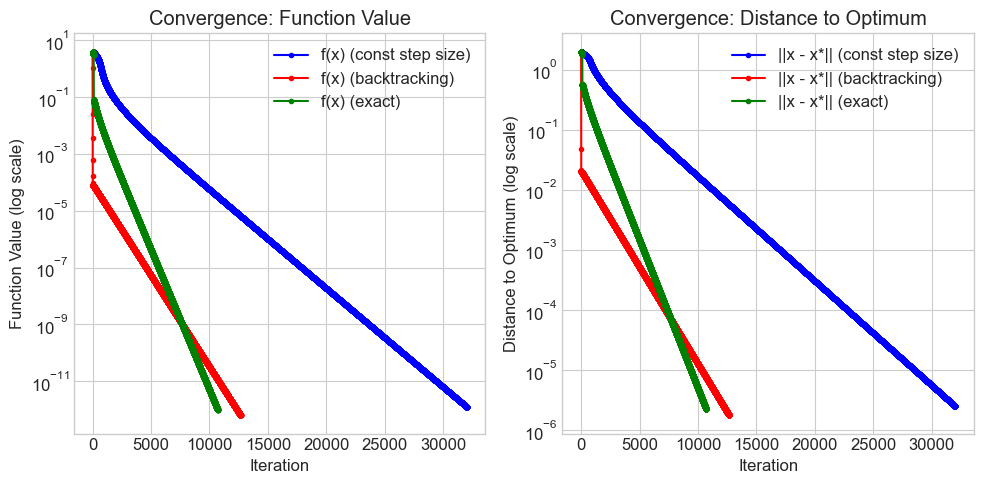

In [132]:
# Problem 4(e): Convergence plot

plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist_c, 'b-o', markersize=3, label='f(x) (const step size)')
plt.semilogy(f_hist_bt, 'r-o', markersize=3, label='f(x) (backtracking)')
plt.semilogy(f_hist_exact, 'g-o', markersize=3, label='f(x) (exact)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([1, 1])  # Known optimum
distances = [norm(x - x_star) for x in x_hist_c]
distances_bt = [norm(x - x_star) for x in x_hist_bt]
distances_exact = [norm(x - x_star) for x in x_hist_exact]
plt.semilogy(distances, 'b-o', markersize=3, label='||x - x*|| (const step size)')
plt.semilogy(distances_bt, 'r-o', markersize=3, label='||x - x*|| (backtracking)')
plt.semilogy(distances_exact, 'g-o', markersize=3, label='||x - x*|| (exact)')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Your Observations for Part (e):

Convergence is much slower. It is initially nonlinear, but settles into a very slow linear convergence. Again, exact line search converges the quickest by iteration count, but constant step size computes faster.


---
# Part 2: Newton's Method (20 points)

Newton's method uses second-order information (the Hessian) to achieve faster convergence:

$$\mathbf{x}_{k+1} = \mathbf{x}_k - [\nabla^2 f(\mathbf{x}_k)]^{-1} \nabla f(\mathbf{x}_k)$$

For quadratic functions, Newton's method converges in **one step**. For general functions, it exhibits **quadratic local convergence** (under appropriate conditions).

## Example: Newton's Method

Here is a complete implementation of Newton's method.

In [133]:
# EXAMPLE: Newton's Method Implementation

def newtons_method(f, grad_f, hess_f, x0, tol=1e-6, max_iter=100):
    """
    Newton's method for unconstrained optimization.
    
    Parameters:
    -----------
    f : function
        Objective function
    grad_f : function
        Gradient of objective function
    hess_f : function
        Hessian of objective function
    x0 : numpy array
        Initial point
    tol : float
        Stopping tolerance
    max_iter : int
        Maximum iterations
        
    Returns:
    --------
    x_history : list
        List of iterates
    f_history : list
        List of function values
    """
    x = x0.copy().astype(float)
    x_history = [x.copy()]
    f_history = [f(x)]
    
    for k in range(max_iter):
        grad = grad_f(x)
        
        # Check stopping criterion
        if norm(grad) < tol:
            print(f"Newton's method converged in {k} iterations!")
            break
        
        # Compute Hessian and Newton direction
        H = hess_f(x)
        
        # Newton step: solve H @ d = -grad
        try:
            d = np.linalg.solve(H, -grad)
        except np.linalg.LinAlgError:
            print("Hessian is singular!")
            break
        
        # Update
        x = x + d
        
        # Store history
        x_history.append(x.copy())
        f_history.append(f(x))
    
    if k == max_iter - 1:
        print(f"Maximum iterations ({max_iter}) reached.")
    
    return x_history, f_history

# Example: Apply to f(x,y) = x^2 + y^2
def hess_f_example(x):
    """Hessian of f(x,y) = x^2 + y^2"""
    return np.array([[2, 0], [0, 2]])

x0 = np.array([5.0, 5.0])
x_hist_newton, f_hist_newton = newtons_method(f_example, grad_f_example, hess_f_example, x0)

print(f"\nFinal point: ({x_hist_newton[-1][0]:.6f}, {x_hist_newton[-1][1]:.6f})")
print(f"Final function value: {f_hist_newton[-1]:.10f}")
print(f"Number of iterations: {len(f_hist_newton) - 1}")
print("\nNote: Newton's method converges in 1 iteration for quadratic functions!")

Newton's method converged in 1 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
Number of iterations: 1

Note: Newton's method converges in 1 iteration for quadratic functions!


---
## Problem 5 (10 points): Newton's Method on Well-Conditioned Problems

Apply Newton's method to the function:

$$f(x, y) = x^2 + 10y^2$$

**Tasks:**

**(a)** Implement the Hessian function `hess_f1`.

**(b)** Run Newton's method from $\mathbf{x}_0 = (5, 5)^T$.

**(c)** How many iterations does Newton's method take? Compare with gradient descent from Problem 1.

**(d)** Create a convergence plot comparing Newton's method with the gradient descent methods from Part 1.

In [134]:
# Problem 5(a): Implement the Hessian

def hess_f1(x):
    """Hessian of f(x,y) = x^2 + 10*y^2"""
    return np.array([[2, 0], [0, 20]])

In [148]:
# Problem 5(b): Run Newton's method
start_time = time.time()
x0 = np.array([5.0, 5.0])

x_hist_newton, f_hist_newton = newtons_method(f1, grad_f1, hess_f1, x0)

print(f"\nFinal point: ({x_hist_newton[-1][0]:.6f}, {x_hist_newton[-1][1]:.6f})")
print(f"Final function value: {f_hist_newton[-1]:.10f}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))


Newton's method converged in 1 iterations!

Final point: (0.000000, 0.000000)
Final function value: 0.0000000000
--- 1.1425018310546875 ms ---


### Your Answer for Part (c):

Newton's method takes one iteration because the function is quadratic. This is 153x less iterations than gradient descent with constant step size, 84x faster than gradient descent with backtracking, and 55x faster than gradient descent with exact line search.


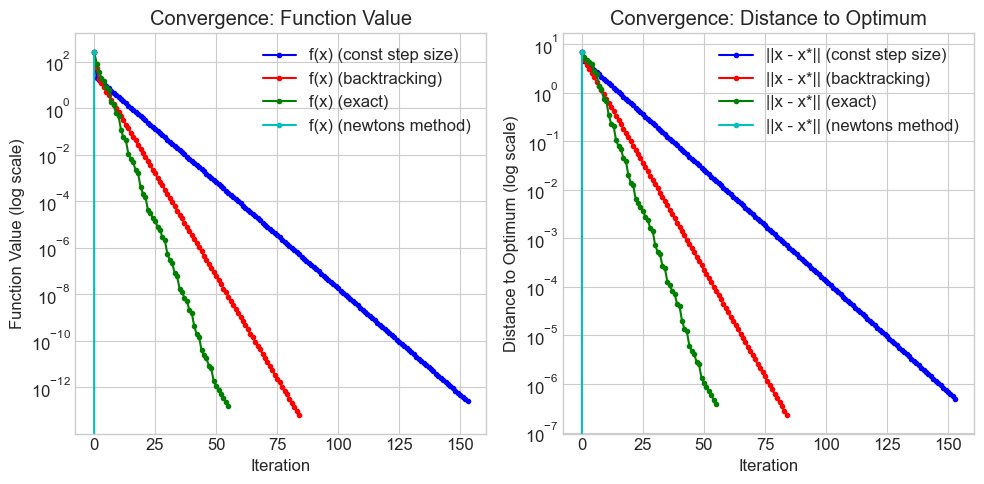

In [ ]:
# Problem 5(d): Convergence plot comparing Newton with gradient descent methods

# NOTE: this requires re-runnig the appropriate blocks to get the correct f_hist values in memory
# I could go back and rename all the variables, but what's the fun in that?
# These should really be two separate python files anyhow

plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist, 'b-o', markersize=3, label='f(x) (const step size)')
plt.semilogy(f_hist_bt, 'r-o', markersize=3, label='f(x) (backtracking)')
plt.semilogy(f_hist_exact, 'g-o', markersize=3, label='f(x) (exact)')
plt.semilogy(f_hist_newton, 'c-o', markersize=3, label='f(x) (newton''s method)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([0, 0])  # Known optimum
distances = [norm(x - x_star) for x in x_hist]
distances_bt = [norm(x - x_star) for x in x_hist_bt]
distances_exact = [norm(x - x_star) for x in x_hist_exact]
distances_newton = [norm(x - x_star) for x in x_hist_newton]
plt.semilogy(distances, 'b-o', markersize=3, label='||x - x*|| (const step size)')
plt.semilogy(distances_bt, 'r-o', markersize=3, label='||x - x*|| (backtracking)')
plt.semilogy(distances_exact, 'g-o', markersize=3, label='||x - x*|| (exact)')
plt.semilogy(distances_newton, 'c-o', markersize=3, label='||x - x*|| (newton''s method)')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


---
## Problem 6 (10 points): Newton's Method on the Rosenbrock Function

Apply Newton's method to the ill-conditioned Rosenbrock function:

$$f(x_1, x_2) = 100(x_2 - x_1^2)^2 + (1 - x_1)^2$$

**Tasks:**

**(a)** Implement the Hessian function `hess_f_rosenbrock`.

**(b)** Run Newton's method from $\mathbf{x}_0 = (-1, 1)^T$.

**(c)** Create a convergence plot comparing Newton's method with gradient descent (from Problem 4).

**(d)** How does Newton's method perform on this ill-conditioned problem compared to gradient descent? Explain why.

In [147]:
# Problem 6(a): Implement the Hessian of Rosenbrock

def hess_f_rosenbrock(x):
    """
    Hessian of Rosenbrock-like function: f(x1,x2) = 100(x2 - x1^2)^2 + (1 - x1)^2
    
    H = [d^2f/dx1^2,    d^2f/dx1dx2]
        [d^2f/dx2dx1,   d^2f/dx2^2 ]
    """
    x1, x2 = x[0], x[1]
    return np.array([[1320*x1**2 - 440*x2 + 2, -440*x1], [-440*x1, 220]])

In [151]:
# Problem 6(b): Run Newton's method on Rosenbrock

start_time = time.time()
x0_ros = np.array([-1.0, 1.0])

x_hist_newton, f_hist_newton = newtons_method(f_rosenbrock, grad_f_rosenbrock, hess_f_rosenbrock, x0_ros)

print(f"\nFinal point: ({x_hist_newton[-1][0]:.6f}, {x_hist_newton[-1][1]:.6f})")
print(f"Final function value: {f_hist_newton[-1]:.10f}")

print("--- %s ms ---" % ((time.time() - start_time)*1000))


Newton's method converged in 2 iterations!

Final point: (1.000000, 1.000000)
Final function value: 0.0000000000
--- 2.0041465759277344 ms ---


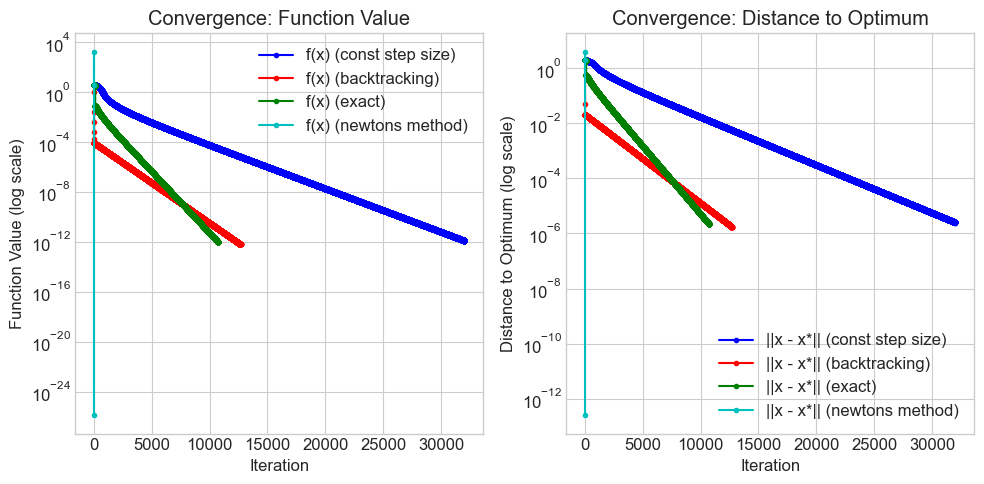

In [154]:
# Problem 6(c): Convergence plot comparing Newton with gradient descent

# NOTE: this requires re-runnig the appropriate blocks to get the correct f_hist values in memory

plt.figure(figsize=(10, 5))

# Plot 1: Function value vs iteration
plt.subplot(1, 2, 1)
plt.semilogy(f_hist_c, 'b-o', markersize=3, label='f(x) (const step size)')
plt.semilogy(f_hist_bt, 'r-o', markersize=3, label='f(x) (backtracking)')
plt.semilogy(f_hist_exact, 'g-o', markersize=3, label='f(x) (exact)')
plt.semilogy(f_hist_newton, 'c-o', markersize=3, label='f(x) (newton''s method)')
plt.xlabel('Iteration')
plt.ylabel('Function Value (log scale)')
plt.title('Convergence: Function Value')
plt.legend()
plt.grid(True)

# Plot 2: Distance to optimum vs iteration
plt.subplot(1, 2, 2)
x_star = np.array([1, 1])  # Known optimum
distances = [norm(x - x_star) for x in x_hist_c]
distances_bt = [norm(x - x_star) for x in x_hist_bt]
distances_exact = [norm(x - x_star) for x in x_hist_exact]
distances_newton = [norm(x - x_star) for x in x_hist_newton]
plt.semilogy(distances, 'b-o', markersize=3, label='||x - x*|| (const step size)')
plt.semilogy(distances_bt, 'r-o', markersize=3, label='||x - x*|| (backtracking)')
plt.semilogy(distances_exact, 'g-o', markersize=3, label='||x - x*|| (exact)')
plt.semilogy(distances_newton, 'c-o', markersize=3, label='||x - x*|| (newton''s method)')
plt.xlabel('Iteration')
plt.ylabel('Distance to Optimum (log scale)')
plt.title('Convergence: Distance to Optimum')
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()

### Your Answer for Part (d):

Newton's method performed significantly better on the ill-conditioned problem. Several thousand less iterations. By compute time, several hundred times faster.


---
# Part 3: Convex Optimization with CVXPY (40 points)

**CVXPY** is a Python library for convex optimization. It allows you to specify optimization problems in a natural way and automatically solves them using efficient algorithms.

**Key Concept:** CVXPY can only solve **convex** optimization problems. Before using CVXPY, you must verify that your problem is convex!

## Example: Introduction to CVXPY

Here's a simple example of solving a convex quadratic program with CVXPY:

$$\min_{x, y} \quad x^2 + y^2$$
$$\text{s.t.} \quad x + y \geq 1$$

In [155]:
# EXAMPLE: CVXPY Introduction

# Step 1: Define variables
x = cp.Variable()
y = cp.Variable()

# Step 2: Define objective function
objective = cp.Minimize(x**2 + y**2)

# Step 3: Define constraints
constraints = [x + y >= 1]

# Step 4: Create and solve the problem
problem = cp.Problem(objective, constraints)
optimal_value = problem.solve()

# Step 5: Print results
print("CVXPY Example: min x^2 + y^2 s.t. x + y >= 1")
print("="*50)
print(f"Status: {problem.status}")
print(f"Optimal value: {optimal_value:.6f}")
print(f"Optimal x: {x.value:.6f}")
print(f"Optimal y: {y.value:.6f}")
print(f"\nVerification: x + y = {x.value + y.value:.6f} >= 1")

CVXPY Example: min x^2 + y^2 s.t. x + y >= 1
Status: optimal
Optimal value: 0.500000
Optimal x: 0.500000
Optimal y: 0.500000

Verification: x + y = 1.000000 >= 1


### CVXPY Syntax Summary

| Task | Syntax |
|------|--------|
| Scalar variable | `x = cp.Variable()` |
| Vector variable | `x = cp.Variable(n)` |
| Minimize | `cp.Minimize(expression)` |
| Maximize | `cp.Maximize(expression)` |
| Equality constraint | `expression == value` |
| Inequality constraint | `expression <= value` or `expression >= value` |
| $l_2$-norm | `cp.norm(x, 2)` |
| Sum of squares | `cp.sum_squares(x)` |
| Quadratic form | `cp.quad_form(x, Q)` |

---
## Problem 7 (10 points): Convex Quadratic Program

Consider the optimization problem:

$$\min_{x_1, x_2} \quad 2x_1^2 + x_2^2 + x_1x_2 - 4x_1 - 6x_2$$
$$\text{s.t.} \quad x_1 + x_2 \leq 3$$
$$\quad\quad\quad x_1 \geq 0, \quad x_2 \geq 0$$

**Tasks:**

**(a)** In the markdown cell below, justify whether this problem is convex.

**(b)** Solve the problem using CVXPY.

**(c)** Report the optimal solution and optimal value.

### Your Answer for Part (a): Convexity Justification

Gradient: $ \nabla f(x_1, x_2) = \begin{bmatrix} 4x_1 + x_2 - 4 \\ 2x_2 + x_1 - 6 \end{bmatrix}$

Hessian: $\nabla^2 f(x_1, x_1) = \begin{bmatrix} 4 & 1 \\ 1 & 2 \end{bmatrix}$

The hessian is positive definite, as it is strictly diagonally dominant with positive diagonal entries. This means the function is convex.

In [166]:
# Problem 7(b) and (c): Solve with CVXPY

# Step 1: Define variables
x = cp.Variable(2)
Q = np.array([[2, 0.5],[0.5, 1]])

# Step 2: Define objective function
objective = cp.Minimize(cp.quad_form(x, Q))

# Step 3: Define constraints
constraints = [x[0] + x[1] <= 3, x[0] >= 0, x[1] >= 0]

# Step 4: Create and solve the problem
problem = cp.Problem(objective, constraints)
optimal_value = problem.solve()

# Step 5: Print results
print(f"Status: {problem.status}")
print(f"Optimal value: {optimal_value:.6f}")
print(f"Optimal x1: {x.value[0]:.6f}")
print(f"Optimal x2: {x.value[1]:.6f}")
print(f"\nVerification: x + y = {x.value[0] + x.value[1]:.6f} <= 3")

Polishing not needed - no active set detected at optimal point
Status: optimal
Optimal value: 0.000000
Optimal x1: 0.000000
Optimal x2: 0.000000

Verification: x + y = 0.000000 <= 3


---
## Problem 8 (10 points): Constrained Optimization with Norm

Consider the optimization problem:

$$\min_{\mathbf{x} \in \mathbb{R}^3} \quad \|\mathbf{x} - \mathbf{a}\|_2$$
$$\text{s.t.} \quad \mathbf{1}^T \mathbf{x} = 1$$
$$\quad\quad\quad \mathbf{x} \geq \mathbf{0}$$

where $\mathbf{a} = (1, 2, 3)^T$ and $\mathbf{1} = (1, 1, 1)^T$.

This problem finds the point on the probability simplex closest to $\mathbf{a}$.

**Tasks:**

**(a)** Justify whether this problem is convex.

**(b)** Solve the problem using CVXPY.

**(c)** Report the optimal solution and verify that the constraints are satisfied.

### Your Answer for Part (a): Convexity Justification

*Double-click to edit this cell and justify whether the problem is convex.*



In [ ]:
# Problem 8(b) and (c): Solve with CVXPY

a = np.array([1, 2, 3])

# YOUR CODE HERE


---
## Problem 9 (10 points): Determine Convexity and Solve

Consider the optimization problem:

$$\min_{x_1, x_2} \quad e^{x_1} + e^{x_2}$$
$$\text{s.t.} \quad x_1 + 2x_2 \geq 3$$
$$\quad\quad\quad x_1 \geq 0$$

**Tasks:**

**(a)** Determine whether this problem is convex. Justify your answer using methods from class (e.g., show the Hessian is PSD, or use preservation rules for convex functions).

**(b)** If the problem is convex, solve it using CVXPY. If not, explain why CVXPY cannot be used.

**(c)** Report the optimal solution and optimal value.

### Your Answer for Part (a): Convexity Determination

*Double-click to edit this cell and determine whether the problem is convex with justification.*



In [ ]:
# Problem 9(b) and (c): Solve with CVXPY (if convex)

# YOUR CODE HERE


---
## Problem 10 (10 points): Non-Convex Problem

Consider the optimization problem:

$$\min_{x_1, x_2} \quad x_1^2 - x_2^2$$
$$\text{s.t.} \quad x_1^2 + x_2^2 \leq 1$$

**Tasks:**

**(a)** Determine whether this problem is convex. Justify your answer.

**(b)** Try to solve this problem using CVXPY. What happens?

**(c)** Explain why CVXPY cannot solve this problem. What would you need to do to solve it?

### Your Answer for Part (a): Convexity Determination

*Double-click to edit this cell and determine whether the problem is convex with justification.*



In [ ]:
# Problem 10(b): Try to solve with CVXPY

# YOUR CODE HERE
# Note: This should produce an error or unexpected behavior!


### Your Answer for Part (c): Explanation

*Double-click to edit this cell and explain why CVXPY cannot solve this problem and what alternatives exist.*



---
# Summary

In this assignment, you have:

1. **Implemented gradient descent** with three step size strategies (constant, backtracking, exact)
2. **Explored the condition number** and its effect on convergence speed
3. **Implemented Newton's method** and compared it with gradient descent
4. **Used CVXPY** to solve convex optimization problems
5. **Learned to identify** whether a problem is convex before attempting to solve it

**Key Takeaways:**
- Gradient descent converges slowly on ill-conditioned problems
- Newton's method uses curvature information to converge faster
- CVXPY is powerful but only works for convex problems
- Always verify convexity before using convex optimization tools!

# Submitting your assignment

After completing this notebook, follow the instructions below to save it as a PDF and then upload that PDF to Gradescope.

---
# How to Export Your Notebook as a PDF

Before exporting, make sure you have:
1. **Run all cells** so all outputs are visible
2. **Completed all markdown cells** with your written answers
3. **Saved your notebook**

---

## VS Code / GitHub Codespaces

1. **Run all cells:** Click **Run All** in the toolbar (or press `Ctrl+Shift+Enter`)

2. **Export to HTML:**
   - Open Command Palette: `Ctrl+Shift+P` (Windows/Linux) or `Cmd+Shift+P` (Mac)
   - Type `Export` and select **"Jupyter: Export to HTML"**
   - Save the HTML file

3. **Convert to PDF:**
   - Open the HTML file in Chrome
   - Press `Ctrl+P` (or `Cmd+P` on Mac)
   - Set **Destination** to **"Save as PDF"**
   - Click **Save**

---

## Google Colab

1. **Run all cells:** Click **Runtime → Run all** (or press `Ctrl+F9`)

2. **Save as PDF:**
   - Go to **File → Print** (or press `Ctrl+P`)
   - Set **Destination** to **"Save as PDF"**
   - Click **Save**

---

## Submission Checklist

- [ ] All code cells have been executed (outputs visible)
- [ ] All written answers are complete
- [ ] Plots and figures are visible
- [ ] PDF is readable and not cut off